# Demo Self-Attention trong Transformer (từng bước)

Notebook này minh họa **cơ chế Self-Attention** — trái tim của kiến trúc Transformer —
bằng cách tự cài đặt (from scratch) với NumPy, đi từng bước từ một câu văn bản đầu vào
cho tới khi ra được **ma trận trọng số attention** và vector đầu ra.

Các bước sẽ thực hiện:
1. Tokenization (tách từ)
2. Embedding (biến từ thành vector)
3. Khởi tạo trọng số $W_Q, W_K, W_V$
4. Tính $Q, K, V$
5. Tính điểm attention (scaled dot-product)
6. Softmax → **trọng số attention**
7. Trực quan hóa heatmap
8. Tính vector đầu ra (weighted sum theo $V$)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)  # để kết quả tái lập được
%matplotlib inline


## Bước 1 — Tokenization

Ta bắt đầu với một câu tiếng Việt đơn giản. Vì đây là demo minh họa cơ chế toán học
của attention (không phải huấn luyện mô hình ngôn ngữ), ta tách câu thành các từ
bằng cách đơn giản là split theo khoảng trắng.

> Bạn có thể đổi câu `sentence` bên dưới thành câu bất kỳ để thử nghiệm.


In [ ]:
sentence = "Tôi yêu học máy"

tokens = sentence.split()
vocab = {word: idx for idx, word in enumerate(tokens)}

print("Câu đầu vào :", sentence)
print("Tokens      :", tokens)
print("Số token    :", len(tokens))


Câu đầu vào : Tôi yêu học máy
Tokens      : ['Tôi', 'yêu', 'học', 'máy']
Số token    : 4


## Bước 2 — Embedding

Mỗi token được ánh xạ thành một vector số thực (embedding). Trong mô hình thật,
các vector này được học từ dữ liệu; ở đây ta khởi tạo ngẫu nhiên (seed cố định)
với số chiều `d_model = 8` để dễ quan sát.


In [ ]:
d_model = 8  # số chiều của embedding

# Mỗi hàng là embedding của 1 token, thứ tự đúng theo câu
X = np.random.randn(len(tokens), d_model)

embedding_df = pd.DataFrame(X, index=tokens,
                             columns=[f"dim_{i}" for i in range(d_model)])
embedding_df.round(3)


,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7
Tôi,0.497,-0.138,0.648,1.523,-0.234,-0.234,1.579,0.767
yêu,-0.469,0.543,-0.463,-0.466,0.242,-1.913,-1.725,-0.562
học,-1.013,0.314,-0.908,-1.412,1.466,-0.226,0.068,-1.425
máy,-0.544,0.111,-1.151,0.376,-0.601,-0.292,-0.602,1.852


## Bước 3 — Khởi tạo trọng số $W_Q$, $W_K$, $W_V$

Self-attention học 3 phép chiếu tuyến tính khác nhau của cùng một embedding đầu vào:
- $W_Q$ để tạo **Query** — "tôi đang tìm gì?"
- $W_K$ để tạo **Key** — "tôi đại diện cho cái gì?"
- $W_V$ để tạo **Value** — "nội dung thực sự tôi mang theo là gì?"

Ta chiếu từ `d_model = 8` xuống `d_k = 4` (số chiều nhỏ hơn) cho gọn.


In [ ]:
d_k = 4  # số chiều của Query/Key
d_v = 4  # số chiều của Value

W_Q = np.random.randn(d_model, d_k) * 0.5
W_K = np.random.randn(d_model, d_k) * 0.5
W_V = np.random.randn(d_model, d_v) * 0.5

print("W_Q shape:", W_Q.shape)
print("W_K shape:", W_K.shape)
print("W_V shape:", W_V.shape)


W_Q shape: (8, 4)
W_K shape: (8, 4)
W_V shape: (8, 4)


## Bước 4 — Tính $Q$, $K$, $V$

$$Q = X W_Q \quad K = X W_K \quad V = X W_V$$


In [ ]:
Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print("Q =\n", pd.DataFrame(Q, index=tokens).round(3), "\n")
print("K =\n", pd.DataFrame(K, index=tokens).round(3), "\n")
print("V =\n", pd.DataFrame(V, index=tokens).round(3))


Q =
          0      1      2      3
Tôi -1.712 -0.800 -0.414  0.638
yêu  1.781 -0.635 -1.341 -1.279
học  1.390 -0.581  0.673  0.537
máy -0.883  0.307 -1.690 -0.706 

K =
          0      1      2      3
Tôi -0.336  0.957 -1.175 -0.879
yêu  1.297 -0.614  0.030 -0.347
học  0.013 -0.718  2.480  1.422
máy -0.471 -1.853  0.595 -2.573 

V =
          0      1      2      3
Tôi  1.162  0.139 -0.209 -1.414
yêu -1.283  1.333 -2.132  0.489
học -0.824  0.017  0.925  0.424
máy  0.275  1.392 -2.915 -0.389


## Bước 5 — Tính điểm attention (Scaled Dot-Product)

Với mỗi cặp token $(i, j)$, điểm attention thể hiện mức độ token $i$ nên "chú ý"
tới token $j$:

$$\text{score} = \frac{Q K^\top}{\sqrt{d_k}}$$

Việc chia cho $\sqrt{d_k}$ giúp ổn định giá trị, tránh softmax bị bão hòa khi
$d_k$ lớn.


In [ ]:
scores = (Q @ K.T) / np.sqrt(d_k)

scores_df = pd.DataFrame(scores, index=tokens, columns=tokens)
scores_df.round(3)


,Tôi,yêu,học,máy
Tôi,-0.133,-0.981,0.217,0.201
yêu,0.747,1.551,-2.333,1.416
học,-1.143,0.996,1.434,-0.280
máy,1.598,-0.570,-2.713,0.330


## Bước 6 — Softmax → Trọng số Attention

Áp dụng softmax theo từng hàng để các trọng số của mỗi token (so với toàn bộ câu)
cộng lại bằng 1:

$$\text{AttentionWeights} = \text{softmax}(\text{score})$$


In [ ]:
def softmax(x, axis=-1):
    x_shift = x - np.max(x, axis=axis, keepdims=True)  # ổn định số học
    exp_x = np.exp(x_shift)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

attention_weights = softmax(scores, axis=-1)

attn_df = pd.DataFrame(attention_weights, index=tokens, columns=tokens)
print("Tổng mỗi hàng (phải = 1.0):", attention_weights.sum(axis=1).round(3))
attn_df.round(3)


Tổng mỗi hàng (phải = 1.0): [1. 1. 1. 1.]


,Tôi,yêu,học,máy
Tôi,0.236,0.101,0.334,0.329
yêu,0.191,0.427,0.009,0.373
học,0.040,0.339,0.526,0.095
máy,0.710,0.081,0.010,0.200


## Bước 7 — Trực quan hóa ma trận trọng số Attention

Heatmap dưới đây cho thấy trực quan: hàng là token "đang nhìn", cột là token
"được nhìn tới", màu càng đậm thì trọng số attention càng lớn.


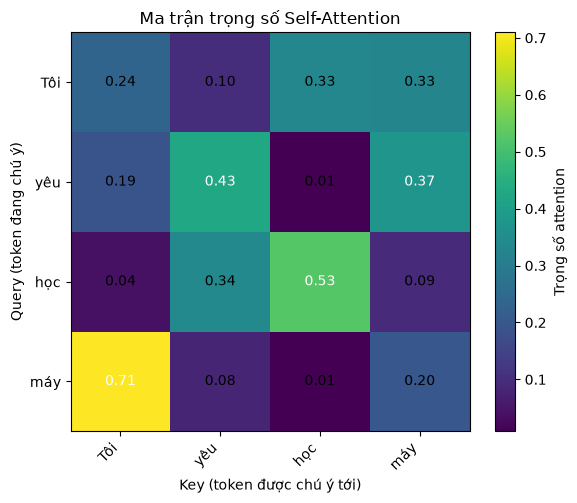

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attention_weights, cmap="viridis")

ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticklabels(tokens)
ax.set_xlabel("Key (token được chú ý tới)")
ax.set_ylabel("Query (token đang chú ý)")
ax.set_title("Ma trận trọng số Self-Attention")

# In số trọng số lên từng ô
for i in range(len(tokens)):
    for j in range(len(tokens)):
        val = attention_weights[i, j]
        color = "white" if val > attention_weights.max() / 2 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color)

fig.colorbar(im, ax=ax, label="Trọng số attention")
plt.tight_layout()
plt.show()


## Bước 8 — Tính vector đầu ra (Weighted Sum theo $V$)

Cuối cùng, output của self-attention cho mỗi token là tổng có trọng số của các
vector $V$, dùng chính trọng số attention vừa tính:

$$\text{Output} = \text{AttentionWeights} \cdot V$$

Vector đầu ra của mỗi token giờ đây đã "pha trộn" thông tin từ các token khác
trong câu, theo đúng mức độ liên quan mà attention đã học được.


In [ ]:
output = attention_weights @ V

output_df = pd.DataFrame(output, index=tokens,
                          columns=[f"dim_{i}" for i in range(d_v)])
output_df.round(3)


,dim_0,dim_1,dim_2,dim_3
Tôi,-0.041,0.631,-0.914,-0.270
yêu,-0.230,1.115,-2.030,-0.203
học,-0.796,0.599,-0.522,0.296
máy,0.768,0.485,-0.895,-1.037


## Tổng kết

| Bước | Ý nghĩa |
|---|---|
| Tokenization | Câu → danh sách token |
| Embedding | Token → vector số |
| $W_Q, W_K, W_V$ | Trọng số học được (ở đây khởi tạo ngẫu nhiên) |
| $Q, K, V$ | Phép chiếu Query / Key / Value |
| Scaled dot-product | Điểm tương đồng giữa các token |
| Softmax | **Trọng số attention** (chuẩn hóa, tổng = 1) |
| Weighted sum với $V$ | Vector đầu ra, đã "trộn" ngữ cảnh |

Đây là **một khối self-attention với 1 head**. Trong Transformer thật, bước này
được lặp lại song song với nhiều "head" khác nhau (Multi-Head Attention), rồi
ghép lại và đưa qua các lớp Feed-Forward + LayerNorm + residual connection để
tạo thành 1 Encoder/Decoder block hoàn chỉnh.
